In [1]:
import numpy as np
import pandas as pd
from math import e
import matplotlib.pyplot as plt
np.random.seed(42)
print("라이브러리 import 완료")

라이브러리 import 완료


In [2]:
# 온도, 습도, 정답 데이터를 직접 만듭니다.
data = {
    "temperature": [10, 15, 20, 25, 30, 35],
    "humidity":    [30, 40, 50, 60, 70, 80],
    "y":           [ 0,  0,  1,  1,  0,  0]
}

df = pd.DataFrame(data)

df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,20,50,1
3,25,60,1
4,30,70,0
5,35,80,0


In [3]:
# df["y"] == 0 은 각 행의 y가 0인지 True/False로 표시
# boolean mask 라고 하며, 뒤 셀에서 조건에 맞는 행만 골라 그릴 때 사용
mask0 = df["y"] == 0
mask1 = df["y"] == 1

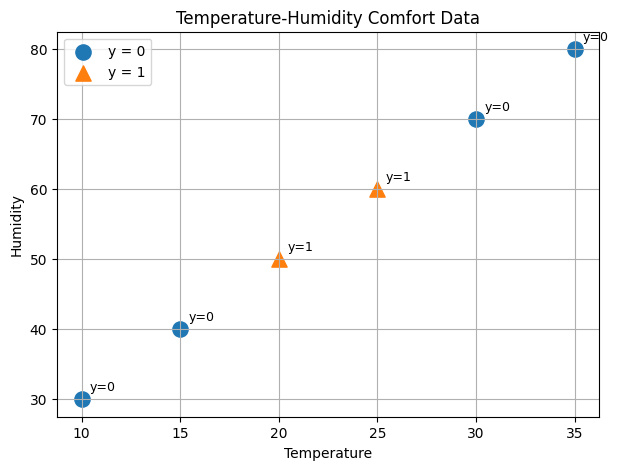

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(df.loc[mask0, "temperature"], df.loc[mask0, "humidity"],
                marker="o", s=120, label="y = 0")

plt.scatter(df.loc[mask1, "temperature"], df.loc[mask1, "humidity"],
                marker="^", s=120, label="y = 1")

# 각 점 옆에 y 값을 작게 표시합니다.
# xytext=(6, 6) 은 글자를 점에서 오른쪽 위로 조금 띄워 표시한다는 뜻입니다.
# textcoords="offset points" 는 xytext 값을 점 기준의 이동 거리로 해석하게 합니다.
for temp, hum, yv in zip(df["temperature"], df["humidity"], df["y"]):
    plt.annotate(f"y={yv}", (temp, hum),
                    textcoords="offset points", xytext=(6, 6), fontsize=9)

# 축 라벨, 제목, 범례, 격자 설정
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature-Humidity Comfort Data")
plt.legend()
plt.grid(True)

plt.show()

In [5]:
# X_raw: 원본 입력값. 온도와 습도를 나란히 붙여 (n, 2) 모양으로 만듭니다.
# shape = (n, 2) -> 열 0 = 온도, 열 1 = 습도
X_raw = df[["temperature", "humidity"]].to_numpy(dtype=float)

# y: 실제 정답. (n, 1) 모양의 ㅔ로 벡터로 만듭니다.
# n 은 데이터 개수입니다. 이번 데이터는 6개이므로 y의 shape는 (6, 1)이 됩니다.
# 뒤에서 계산할 H_output, z_output도 shape가 (6, 1)이므로, y와 모양이 딱 맞아
# Cost 계산이 안전하게 됩니다. (모양이 안 맞으면 계싼에서 에러가 나거나 값이 이상해집니다.)
y = df["y"].to_numpy(dtype=float).reshape(-1, 1)

In [6]:
# X_mean: 각 입력 컬럼(온도, 습도)의 평균. axis=0 은 "열 방향 계산"=컬럼별 평균 이라는 뜻입니다.
#   keepdims=True 로 (1, 2) 모양을 유지해 브로드캐스팅이 쉽게 되도록 합니다.
X_mean = X_raw.mean(axis=0, keepdims=True)  # shape = (1, 2)

# X_std: 각 입력 컬럼의 표준편차
X_std = X_raw.std(axis=0, keepdims=True)    # shape = (1, 2)

print("X_mean (온도평균, 습도평균):", X_mean)
print("X_std (온도표준편차, 습도표준편차):", X_std)

X_mean (온도평균, 습도평균): [[22.5 55. ]]
X_std (온도표준편차, 습도표준편차): [[ 8.53912564 17.07825128]]


In [7]:
# X_norm: 정ㄱ화된 입력값. (원본 - 평균) / 표준편차
#
# [정규화를 왜, 어디에 쓰는지 정리]
#   - 학습(Gradient Descent)에는 정규화된 값 X_norm을 사용합니다.
#       -> 온도(10~35)와 습도(30~80)처럼 단위와 범위가 서로 다른 값을 
#           그대로 넣으면 학습이 불안정해질 수 있기 때문
#   - 반대로 결과 해석과 그래프에는 원래 온도, 습도 단위(X_raw)를 사용
#       -> 사람은 "온도 25도, 습도 55%" 처럼 원래 단위가 이해하기 쉽기 때문
#
# 정규화 후에는 각 입력이 평균(0) 근처를 중심으로 비교적 비슷한 크기의 숫자가 됩니다.
X_norm = (X_raw - X_mean) / X_std   # shape = (n, 2)

In [8]:
# X_raw, y, X_norm 의 shape를 확인합니다.
print("X_raw shape:", X_raw.shape, " <- n=6 이므로 (6, 2)")
print("y shape:", y.shape," <- (6, 1)")
print("x_norm shape:", X_norm.shape, " <- n=6 이므로 (6, 2)")

X_raw shape: (6, 2)  <- n=6 이므로 (6, 2)
y shape: (6, 1)  <- (6, 1)
x_norm shape: (6, 2)  <- n=6 이므로 (6, 2)


In [9]:
# 정규화된 값을 DataFrame 에 새 컬럼으로 추가해 원본과 함께 보기
df["temperature_norm"] = X_norm[:, 0]   # 정규화된 온도
df["humidity_norm"] = X_norm[:, 1]      # 정규화된 습도

df

,temperature,humidity,y,temperature_norm,humidity_norm
0,10,30,0,-1.46385,-1.46385
1,15,40,0,-0.87831,-0.87831
2,20,50,1,-0.29277,-0.29277
3,25,60,1,0.29277,0.29277
4,30,70,0,0.87831,0.87831
5,35,80,0,1.46385,1.46385


In [10]:
def sigmoid(H):
    # H는 sigmoid 이전의 선형 출력값입니다. (확률아님)
    # H가 아주 크거나 아주 작으면 exp 계산에서 overflow가 날 수 있습니다.
    # 그래서 H를 -500 ~ 500 사이로 잘라(clip) 계산을 안정적으로 만듭니다.
    H_clip = np.clip(H, -500, 500)

    # sigmoid 공식: 1 / (1 + e**(-H))
    # 반환값 z는 항상 0과 1사이의 값입니다.
    z = 1.0 / (1.0 + e**(-H_clip))
    return z

# 동작 확인: H=0이면 z=0.5, H가 크면 z는 1에 가까워지고, H가 작으면 z는 0에 가까워집니다.
print("sigmoid(0) =", sigmoid(np.array(0.0)))
print("sigmoid(10) =", sigmoid(np.array(10.0)))
print("sigmoid(-10) =", sigmoid(np.array(-10.0)))

sigmoid(0) = 0.5
sigmoid(10) = 0.9999546021312976
sigmoid(-10) = 4.539786870243442e-05


In [11]:
def bce_cost(y, z):
    # y: 실제 정답 (0 or 1), z: 예측확률 (0 ~ 1)
    # MLP에서는 최종 예측확률 z_output를 이 함수의 z 자리에 넣어 Cost를 계산합니다.
    epsilon = 1e-7

    # z를 [epsilon, 1-epsilon] 범위로 잘라 log계산을 안정적으로 만듭니다.
    z_clip = np.clip(z, epsilon, 1.0 - epsilon)

    # BCE 공식: -[y*log(z) + (1-y)*log(1-z)]
    # 각 데이터마다 값이 나오므로, 평균(mean)을 내어 하나의 Cost로 만듭니다.
    cost = -(y * np.log(z_clip) + (1.0 - y) * np.log(1.0 - z_clip))

    # 반환값은 전체 데이터에 대한 '평균 Cost' 입니다.
    return np.mean(cost)

In [12]:
# 동작확인: 정답과 예측이 비슷하면 Cost가 작고, 반대면 큼
y_test = np.array([[1.0], [0.0]])
z_good = np.array([[0.9], [0.1]])
z_bad  = np.array([[0.1], [0.9]])
print("잘 맞춘 경우 Cost:", bce_cost(y_test, z_good))
print("크게 틀린 경우 Cost:", bce_cost(y_test, z_bad))

잘 맞춘 경우 Cost: 0.10536051565782628
크게 틀린 경우 Cost: 2.302585092994046


In [13]:
# 학습에 사용할 입력을 교재 표기(X1, X2)에 맞게 준비합니다.
# 정규화된 온도/ 습도 열을 각각 (n, 1) 세로 벡터로 꺼냅니다.
#   - X_norm[:, [0]]는 세로벡터(온도)
#   - X_norm[:, [1]]는 세로벡터(습도)
# y도 (n, 1)이므로 계싼할 때 모양이 딱 맞음
X1_norm = X_norm[:, [0]]
X2_norm = X_norm[:, [1]]

In [14]:
# MLP 파라미터(가중치, 편향)를 숫자 하나씩 초기화
# np.random.randn() 은 평균 0, 표준편차 1의 정규분포 난수를 하나 만듭니다.
# 여기에 0.1을 곱해 처음에는 '작은 값'에서 학습을 시작하도록 합니다.
#   - 왜 작은 값에서 시작하나요?
#       처음부터 가중치가 너무 크면 sigmoid 출력이 0 또는 1에 너무 가까이 붙어
#       학습이 잘 진행되지 않고 불안정해질 수 있기 때문입니다.

# 히든 뉴런 1
a11 = np.random.randn() * 0.1   # X1(온도) -> 히든 뉴런 1 가중치
a12 = np.random.randn() * 0.1   # X2(습도) -> 히든 뉴런 1 가중치
b1 = 0.0                        # 히든 뉴런 1 편향 (0에서 시작해도 학습으로 업데이트됨)

# 히든 뉴런 2
a21 = np.random.randn() * 0.1   # X1(온도) -> 히든 뉴런 2 가중치
a22 = np.random.randn() * 0.1   # X2(습도) -> 히든 뉴런 2 가중치
b2 = 0.0                        # 히든 뉴런 2 편향

# 출력층
a31 = np.random.randn() * 0.1   # z_hidden_1 -> 출력층 가중치
a32 = np.random.randn() * 0.1   # z_hidden_2 -> 출력층 가중치
b3 = 0.0                        # 출력층 편향

In [15]:
# 초기 파라미터를 표(DataFrame)로 정리해 확인합니다.
param_table = pd.DataFrame({
    "name":     ["a11", "a12", "b1", "a21", "a22", "b2", "a31", "a32", "b3"],
    "value":    [round(v, 4) for v in [a11, a12, b1, a21, a22, b2, a31, a32, b3]],
    "meaning":[
        "X1(온도) -> 히든 뉴런 1 가중치",
        "X2(습도) -> 히든 뉴런 1 가중치",
        "히든 뉴런 1 편향",
        "X1(온도) -> 히든 뉴런 2 가중치",
        "X2(습도) -> 히든 뉴런 2 가중치",
        "히든 뉴런 2 편향",
        "z_hidden_1 -> 출력층 가중치",
        "z_hidden_2 -> 출력층 가중치",
        "출력층 편향"
    ]
})

param_table

,name,value,meaning
0,a11,0.0497,X1(온도) -> 히든 뉴런 1 가중치
1,a12,-0.0138,X2(습도) -> 히든 뉴런 1 가중치
2,b1,0.0000,히든 뉴런 1 편향
3,a21,0.0648,X1(온도) -> 히든 뉴런 2 가중치
4,a22,0.1523,X2(습도) -> 히든 뉴런 2 가중치
5,b2,0.0000,히든 뉴런 2 편향
6,a31,-0.0234,z_hidden_1 -> 출력층 가중치
7,a32,-0.0234,z_hidden_2 -> 출력층 가중치
8,b3,0.0000,출력층 편향


In [16]:
def mlp_forward_textbook_style(
    X1, X2,
    a11, a12, b1,
    a21, a22, b2,
    a31, a32, b3,
):
    # 이함수는 '학습'을 하는 함수가 아니라, 현재 파라미터로 예측확률(z_output)을 계산하는 '순전파' 함수입니다.
    #

    # 히든뉴런 1
    H_hidden_1 = a11 * X1 + a12 * X2 + b1
    z_hidden_1 = sigmoid(H_hidden_1)

    # 히든뉴런 2
    H_hidden_2 = a21 * X1 + a22 * X2 + b2
    z_hidden_2 = sigmoid(H_hidden_2)

    # 출력층
    H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3
    z_output = sigmoid(H_output)

    return H_hidden_1, z_hidden_1, H_hidden_2, z_hidden_2, H_output, z_output

In [17]:
# 함수를 초기 파라미터로 한 번 실행해서 각 값의 shape를 확인
# 인자 순서는 함수 정의부와 같습니다:
#   X1_norm, X2_norm -> 히든 뉴런 1 -> 히든 뉴런 2 -> 출력층
H_hidden_1, z_hidden_1, H_hidden_2, z_hidden_2, H_output, z_output = mlp_forward_textbook_style(
    X1_norm, X2_norm,
    a11, a12, b1,
    a21, a22, b2,
    a31, a32, b3,
)

# shape 확인 표를 pandas DataFrame으로 정리합니다.
forward_shape_table = pd.DataFrame({
    "name":     ["H_hidden_1", "z_hidden_1", "H_hidden_2", "z_hidden_2", "H_output", "z_output"],
    "shape":    [str(H_hidden_1.shape), str(z_hidden_1.shape), str(H_hidden_2.shape),
                 str(z_hidden_2.shape), str(H_output.shape), str(z_output.shape)],
    "meaning": [
        "히든 뉴런 1 선형 출력",
        "히든 뉴런 1 출려(중간 출력값)",
        "히든 뉴런 2 선형 출력",
        "히든 뉴런 2 출려(중간 출력값)",
        "출력층 선형 출력",
        "최종 예측확률"
    ]
})
forward_shape_table

,name,shape,meaning
0,H_hidden_1,"(6, 1)",히든 뉴런 1 선형 출력
1,z_hidden_1,"(6, 1)",히든 뉴런 1 출려(중간 출력값)
2,H_hidden_2,"(6, 1)",히든 뉴런 2 선형 출력
3,z_hidden_2,"(6, 1)",히든 뉴런 2 출려(중간 출력값)
4,H_output,"(6, 1)",출력층 선형 출력
5,z_output,"(6, 1)",최종 예측확률


In [18]:
# MLP 학습
# 파라미터는 위 파라미터 초기화 셀에서 이미 초기화 된 값을 그대로 이어서 사용

# 학습설정
learning_rate = 0.5
epochs = 30000

# trace_row_idx: 학습 도중 '관찰할 대표 데이터 1개'의 번호(행 위치) 입니다.
trace_row_idx = 0

# 데이터 개수 n(gradient를 평균 낼 때 사용)
n = X1_norm.shape[0]    # n은 학습 데이터 개수입니다. 현재 데이터는 6개입니다.

In [19]:
# 학습 과정의 Cost를 저장할 리스트
cost_history = []

for epoch in range(epochs):
    # 순전파 (forward): X1, X2 -> H_hidden_1, H_hidden_2 -> z_hidden_1, z_hidden_2 -> H_output -> z_output -> Cost
    H_hidden_1 = a11 * X1_norm + a12 * X2_norm + b1
    z_hidden_1 = sigmoid(H_hidden_1)
    H_hidden_2 = a21 * X1_norm + a22 * X2_norm + b2
    z_hidden_2 = sigmoid(H_hidden_2)
    H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3
    z_output = sigmoid(H_output)
    cost = bce_cost(y, z_output)
    cost_history.append(cost)

    # gradient는 Cost를 줄이기 위해 각 파라미터를 어느 방햐응로 움직일지 알려주는 값입니다.
    # 출력층에서 시작한 변화량을 히든층 쪽으로 거꾸로 전달합니다. (자세한 유도는 다음 강의)
    # [주의] 아래 gradient 공식이 '왜' 이렇게 나오는지는 다음 강의에서 자세히 유도

    # dH_output = z_ouptut - y 는 출력층에서 시작하는 gradient 신호입니다.
    # - 이 값은 '일반적인 오차'가 아니라, BCE Cost와 sigmoid를 함께 미분했을 때 나오는 값
    dH_output = z_output - y
    grad_a31 = np.mean(dH_output * z_hidden_1)
    grad_a32 = np.mean(dH_output * z_hidden_2)
    grad_b3 = np.mean(dH_output)

    # dH_hidden_1: 출력층의 gradient 신호(dH_output)가 히든 뉴런 1 쪽으로 전달된 값입니다. 
    # (z_hidden_1*(1-z_hidden_1)은 sigmoid 미분값)
    dH_hidden_1 = (dH_output * a31) * z_hidden_1 * (1 - z_hidden_1)
    grad_a11 = np.mean(dH_hidden_1 * X1_norm)
    grad_a12 = np.mean(dH_hidden_1 * X2_norm)
    grad_b1 = np.mean(dH_hidden_1)

    # dH_hidden_2: 출력층의 gradient 신호(dH_output)가 히든 뉴런 2 쪽으로 전달된 값입니다. 
    # (z_hidden_2*(1-z_hidden_2)은 sigmoid 미분값)
    dH_hidden_2 = (dH_output * a32) * z_hidden_2 * (1 - z_hidden_2)
    grad_a21 = np.mean(dH_hidden_2 * X1_norm)
    grad_a22 = np.mean(dH_hidden_2 * X2_norm)
    grad_b2 = np.mean(dH_hidden_2)

    # 파라미터 업데이트
    # gradient는 Cost가 '증가'하는 방향이므로, Cost를 줄이려면 그 반대 방향으로 이동하기 위해 뺍니다.
    # MLP는 수정할 파라미터가 9개라 코드가 길어질 뿐, 원리는 단일 퍼셉트론과 같습니다.
    # 순전파 -> Cost 계산 -> gradient 계산 -> 파라미터 업데이트
    a31 = a31 - learning_rate * grad_a31
    a32 = a32 - learning_rate * grad_a32
    b3 = b3 - learning_rate * grad_b3

    a11 = a11 - learning_rate * grad_a11
    a12 = a12 - learning_rate * grad_a12
    b1 = b1 - learning_rate * grad_b1
    
    a21 = a21 - learning_rate * grad_a21
    a22 = a22 - learning_rate * grad_a22
    b2 = b2 - learning_rate * grad_b2
    # ===== 대표 데이터 1개의 순전파 값 출력 =====
    #   - epoch < 5             : 학습 맨 처음(0,1,2,3,4)에는 값이 빠르게 변하므로 매번 출력합니다.
    #   - epoch > 0 and epoch % 3000 == 0 : 그 뒤에는 3000번마다 한 번씩만 출력합니다. (3000, 6000, 9000 ...)
    #   - -> epoch > 0 을 붙인 이유는, epoch 0 은 이미 위의 epoch < 5 에서 출력되므로
    #        중복해서 출력하지 않도록 하기 위해서입니다.
    if epoch < 5 or (epoch > 0 and epoch % 3000 == 0):
        # 대표 데이터 1개(trace_row_idx 번째)의 값만 꺼냅니다.
        # H_hidden_1, z_hidden_1, H_hidden_2, z_hidden_2, H_output, z_output 는 모두 (n, 1) 모양이라, [trace_row_idx, 0] 으로 그 행의 숫자 하나를 꺼냅니다.
        X1_t = X1_norm[trace_row_idx, 0]   # 이 데이터의 입력 X1 (정규화된 온도)
        X2_t = X2_norm[trace_row_idx, 0]   # 이 데이터의 입력 X2 (정규화된 습도)
        y_t = int(y[trace_row_idx, 0])     # 이 데이터의 실제 정답 (0 또는 1)
        # H_hidden_1, H_hidden_2 : Hidden Layer 에서 sigmoid 를 적용하기 '전'의 선형 계산값입니다. (아직 확률이 아님)
        H_hidden_1_t = H_hidden_1[trace_row_idx, 0]
        H_hidden_2_t = H_hidden_2[trace_row_idx, 0]
        # z_hidden_1, z_hidden_2 : H_hidden_1, H_hidden_2 에 sigmoid 를 적용한 값. Hidden Layer 의 '중간 결과'입니다. (항상 0~1)
        z_hidden_1_t = z_hidden_1[trace_row_idx, 0]
        z_hidden_2_t = z_hidden_2[trace_row_idx, 0]
        # H_output : Output Layer 에서 sigmoid 이전의 선형 계산값입니다.
        #      중요) Output Layer 는 원본 X1, X2 가 아니라, Hidden Layer 가 만든 z_hidden_1, z_hidden_2 를 입력으로 받습니다.
        H_output_t = H_output[trace_row_idx, 0]
        # z_output : sigmoid(H_output) 의 결과이자, 이 데이터의 최종 예측확률입니다. (항상 0~1)
        z_output_t = z_output[trace_row_idx, 0]
        # pred : z_output 가 0.5 이상이면 1, 미만이면 0 으로 정한 최종 예측 클래스입니다.
        pred_t = 1 if z_output_t >= 0.5 else 0
        print(f"[epoch {epoch}]")
        print(f"cost = {cost:.6f}")
        print()
        print(f"[대표 데이터] (X1, X2 는 학습에 쓰는 정규화된 입력값입니다)")
        print(f"X1 = {X1_t:.4f}   (원본 온도 = {X_raw[trace_row_idx, 0]:.1f})")
        print(f"X2 = {X2_t:.4f}   (원본 습도 = {X_raw[trace_row_idx, 1]:.1f})")
        print(f"y = {y_t}")
        print()
        print(f"[Hidden Layer] (H = sigmoid 이전 선형 계산값, z = sigmoid 이후 중간 결과)")
        print(f"H_hidden_1 = {H_hidden_1_t:8.4f} -> z_hidden_1 = {z_hidden_1_t:.4f}")
        print(f"H_hidden_2 = {H_hidden_2_t:8.4f} -> z_hidden_2 = {z_hidden_2_t:.4f}")
        print()
        print(f"[Output Layer] (원본 X1, X2 가 아니라 z_hidden_1, z_hidden_2 를 입력으로 받습니다)")
        print(f"Output Layer 입력: z_hidden_1={z_hidden_1_t:.4f}, z_hidden_2={z_hidden_2_t:.4f}")
        print(f"H_output = {H_output_t:8.4f} -> z_output = {z_output_t:.4f}")
        print()
        print(f"[최종 예측] (z_output 가 0.5 이상이면 1, 미만이면 0)")
        print(f"z_output = {z_output_t:.4f} -> pred = {pred_t}")
        print("-" * 60)
        print("-" * 60)
    if epoch % 100 == 0 or epoch == epochs -1:
        print(f"학습 종료 | 최종 cost={cost_history[-1]:.6f}")
        print("학습된 파라미터:")
        print(f"  히든 뉴런 1: a11={a11:.4f}, a12={a12:.4f}, b1={b1:.4f}")
        print(f"  히든 뉴런 2: a21={a21:.4f}, a22={a22:.4f}, b2={b2:.4f}")
        print(f"  출력층     : a31={a31:.4f}, a32={a32:.4f}, b3={b3:.4f}")

[epoch 0]
cost = 0.689314

[대표 데이터] (X1, X2 는 학습에 쓰는 정규화된 입력값입니다)
X1 = -1.4639   (원본 온도 = 10.0)
X2 = -1.4639   (원본 습도 = 30.0)
y = 0

[Hidden Layer] (H = sigmoid 이전 선형 계산값, z = sigmoid 이후 중간 결과)
H_hidden_1 =  -0.0525 -> z_hidden_1 = 0.4869
H_hidden_2 =  -0.3178 -> z_hidden_2 = 0.4212

[Output Layer] (원본 X1, X2 가 아니라 z_hidden_1, z_hidden_2 를 입력으로 받습니다)
Output Layer 입력: z_hidden_1=0.4869, z_hidden_2=0.4212
H_output =  -0.0213 -> z_output = 0.4947

[최종 예측] (z_output 가 0.5 이상이면 1, 미만이면 0)
z_output = 0.4947 -> pred = 0
------------------------------------------------------------
------------------------------------------------------------
학습 종료 | 최종 cost=0.689314
학습된 파라미터:
  히든 뉴런 1: a11=0.0497, a12=-0.0138, b1=0.0005
  히든 뉴런 2: a21=0.0648, a22=0.1523, b2=0.0005
  출력층     : a31=-0.0636, a32=-0.0636, b3=-0.0804
[epoch 1]
cost = 0.671735

[대표 데이터] (X1, X2 는 학습에 쓰는 정규화된 입력값입니다)
X1 = -1.4639   (원본 온도 = 10.0)
X2 = -1.4639   (원본 습도 = 30.0)
y = 0

[Hidden Layer] (H = sigmoid 이전 선형 계산값, z = sigmoid 

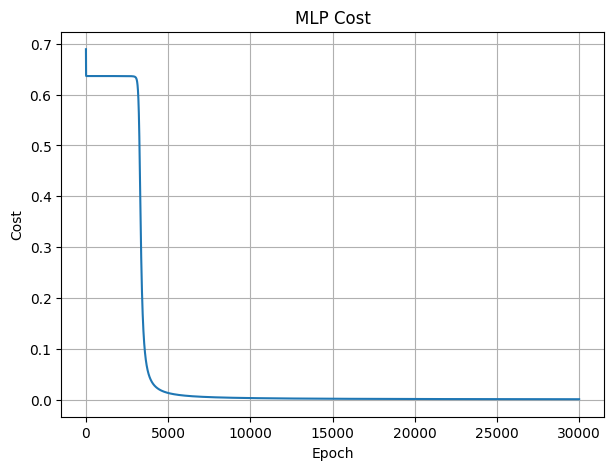

In [20]:
plt.figure(figsize=(7, 5))

# x축: epoch 번호, y축: 그 때의 Cost
plt.plot(range(len(cost_history)), cost_history)

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("MLP Cost")
plt.grid(True)

plt.show()

In [21]:
# 학습이 끝난 뒤, 학습된 9개 파라미터로 순전파를 '다시' 실행해 각 데이터의 최종 예측확률을 구합니다.
# (학습 루프 안의 값이 아니라, 최종 파라미터 기준의 결과를 표로 확인하기 위해서입니다.)
# 인자 순서는 함수 정의부와 같습니다: X1_norm, X2_norm -> 히든1 -> 히든2 -> 출력층(a31, a32, b3)
H_hidden_1_final, z_hidden_1_final, H_hidden_2_final, z_hidden_2_final, H_output_final, z_output_final = mlp_forward_textbook_style(
    X1_norm, X2_norm,
    a11, a12, b1,
    a21, a22, b2,
    a31, a32, b3
)
z_output_final

array([[3.23710433e-04],
       [6.26205722e-04],
       [9.98827033e-01],
       [9.98836574e-01],
       [6.23274907e-04],
       [3.26414558e-04]])

In [22]:
# 최종 예측확률 z_output 가 0.5 이상이면 1, 아니면 0 으로 판정합니다.
#  - (z_output_final >= 0.5) 는 True/False 를 만들고, .astype(int) 가 이를 1/0 으로 바꿉니다.
pred_mlp = (z_output_final >= 0.5).astype(int)

In [23]:
# (1) MLP 예측 결과 표: 원본 입력(온도·습도), 실제 정답, 예측확률(z_output), 예측 클래스를 한 번에 비교하기 위한 표입니다.
result_df = pd.DataFrame({
    "temperature": df["temperature"].to_numpy(),
    "humidity": df["humidity"].to_numpy(),
    "y_actual": y.astype(int).ravel(),                   # 실제 정답
    "z_output_probability": np.round(z_output_final.ravel(), 4),   # 최종 예측확률 (소수 4자리)
    "mlp_pred": pred_mlp.ravel(),                         # 예측 클래스(0/1)
})

In [24]:
# is_correct: MLP 예측(mlp_pred)이 실제 정답(y_actual)과 같은지 확인하는 열입니다. (같으면 True)
result_df["is_correct"] = result_df["y_actual"] == result_df["mlp_pred"]

# 전체 결과 표를 출력합니다.
result_df

,temperature,humidity,y_actual,z_output_probability,mlp_pred,is_correct
0,10,30,0,0.0003,0,True
1,15,40,0,0.0006,0,True
2,20,50,1,0.9988,1,True
3,25,60,1,0.9988,1,True
4,30,70,0,0.0006,0,True
5,35,80,0,0.0003,0,True


In [25]:
# 순전파 확인용 표 : MLP 내부 계산값을 각 데이터마다 한 행씩 확인하기 위한 표입니다.
# 교재의 순전파 단계를 그대로 보여줍니다
# - H계열은 sigmoid 이전 값이라 음수, 0, 양수 모두 가능
# - z계열은 sigmoid 이후 값이라 항상 0과 1 사이
# - z_output가 최종 예측 활률이며, 위 결과 표의 z_ouput_probability와 같은 값
forward_trace_df = pd.DataFrame({
    "temperature": df["temperature"].to_numpy(),
    "humidity": df["humidity"].to_numpy(),
    "y_actual": y.astype(int).ravel(),
    "H_hidden_1": np.round(H_hidden_1_final.ravel(), 4),
    "z_hidden_1": np.round(z_hidden_1_final.ravel(), 4),
    "H_hidden_2": np.round(H_hidden_2_final.ravel(), 4),
    "z_hidden_2": np.round(z_hidden_2_final.ravel(), 4),
    "H_output": np.round(H_output_final.ravel(), 4),
    "z_output": np.round(z_output_final.ravel(), 4),
})
forward_trace_df

,temperature,humidity,y_actual,H_hidden_1,z_hidden_1,H_hidden_2,z_hidden_2,H_output,z_output
0,10,30,0,9.5227,0.9999,-22.7221,0.0000,-8.0353,0.0003
1,15,40,0,3.0984,0.9568,-16.2619,0.0000,-7.3752,0.0006
2,20,50,1,-3.3260,0.0347,-9.8017,0.0001,6.7470,0.9988
3,25,60,1,-9.7503,0.0001,-3.3415,0.0342,6.7552,0.9988
4,30,70,0,-16.1746,0.0000,3.1187,0.9577,-7.3799,0.0006
5,35,80,0,-22.5989,0.0000,9.5788,0.9999,-8.0270,0.0003


In [26]:
# 시각화를 위한 온도, 습도 격자를 만듭니다. (여기서는 예측/그림 없이 격자만 준비)
# 기존 데이터 범위보다 약간 넓게 잡아 바깥쪽가지 보이도록
temp_min = df["temperature"].min() - 2
temp_max = df["temperature"].max() + 2
hum_min = df["humidity"].min() - 2
hum_max = df["humidity"].max() + 2

# 온도 축과 습도 축을 각각 200개의 점으로 나눕니다
# np.linspace는 최솟값부터 최댓값까지 일정한 간격의 숫자를 만듭니다.
temp_grid = np.linspace(temp_min, temp_max, 200)
hum_grid = np.linspace(hum_min, hum_max, 200)

# np.meshgrid는 온도축과 습도축을 조합해, 배경을 칠할 모든 좌표를 만듭니다
# meshgrid로 (200, 200) 격자를 만듭니다. (TEMP=온도, HUM=습도)
TEMP, HUM = np.meshgrid(temp_grid, hum_grid)

print("TEMP shape:", TEMP.shape, " | HUM shape:", HUM.shape)

TEMP shape: (200, 200)  | HUM shape: (200, 200)


In [27]:
# 격자 데이터도 학습 때와 '같은' 평균(X_mean)과 표준편차(X_std)로 정규화
TEMP_norm = (TEMP - X_mean[0, 0]) / X_std[0, 0] # 정규화된 온도 격자
HUM_norm = (HUM - X_mean[0, 1]) / X_std[0, 1]   # 정규화된 습도 격자

In [28]:
# 격자의 모든 점을 1차원으로 펼쳐 학습된 MLP에 넣습니다.
# ravel()은 2차원 격자를 1차원으로 펼칩니다. (MLP 함수에 한 번에 넣기 위해서입니다.)
grid_X1 = TEMP_norm.ravel()
grid_X2 = HUM_norm.ravel()

# 학습이 끝난 파라미터로 순전파를 실행합니다. (반환값 중 최종 예측확률 z_output만 사용)
# _ 는 반환값 중 이번 셀에서 사용하지 않는 값을 받는 자리
_, _, _, _, _, grid_z_output = mlp_forward_textbook_style(
    grid_X1, grid_X2,
    a11, a12, b1,
    a21, a22, b2,
    a31, a32, b3
)

# z_ouput가 0.5이상이면 1, 아니면 0으로 예측한 뒤, 다시 격자 모양으로 되돌립니다.
grid_pred = (grid_z_output >= 0.5).astype(int)
grid_pred_2d = grid_pred.reshape(TEMP.shape)

print("gird_pred_2d shape:", grid_pred_2d.shape)

gird_pred_2d shape: (200, 200)


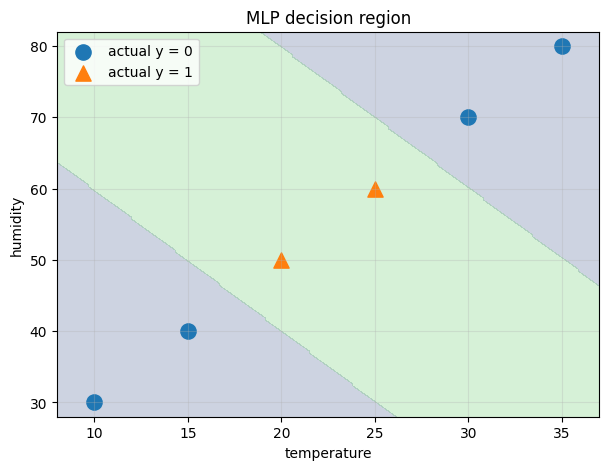

In [29]:
plt.figure(figsize=(7, 5))

# 배경: MLP가 0으로 예측한 영역과 1로 예측한 영역
# contourf 는 격자 위의 예측값 0/1 에 따라 배경 영역을 칠합니다.
# levels는 예측값 0과 1이 서로 다른 영역으로 보이도록 나누는 경계입니다.
# alpha=0.25는 배경색을 연하게 만들어 실제 데이터 점이 가려지지 않게 합니다.
plt.contourf(TEMP, HUM, grid_pred_2d, alpha=0.25, levels=[-0.5, 0.5, 1.5])

# 실제 데이터 점을 배경 위에 표시합니다.
# s=120은 점 크기를 키워 데이터 위치를 보기 쉽게 하고, label은 범례에 표시될 이름입니다.
mask0 = df["y"] == 0
mask1 = df["y"] == 1

plt.scatter(df.loc[mask0, "temperature"], df.loc[mask0, "humidity"],
                    marker="o", s=120, label="actual y = 0")
plt.scatter(df.loc[mask1, "temperature"], df.loc[mask1, "humidity"],
                    marker="^", s=120, label="actual y = 1")

plt.xlabel("temperature")
plt.ylabel("humidity")
plt.title("MLP decision region")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()